## Noise Bliss
###### https://github.com/calanuzao/noise-bliss
Denoising Algorithms for Acoustic Scene Classification in Deep Learning Models with the SONYC-UST Dataset

### Library Imports and Setup

In [1]:
# Install additional library for TensorFlow I/O operations (only needed once)
%pip install tensorflow-io
# -------- Core Libraries --------
import tensorflow as tf       # TensorFlow for deep learning
import utils as u             # Custom utilities module
import models as m            # Custom models module

# -------- Visualization and Display --------
import IPython.display as ipd  # For displaying audio in Jupyter notebooks
import matplotlib.pyplot as plt  # For plotting graphs and figures
import tqdm
from tqdm import tqdm

# -------- File Handling and Data Processing --------
import os                     # Operating system utilities
import pandas as pd           # Data handling and manipulation (DataFrames)
import random                 # For generating random numbers

# -------- Audio Processing --------
import torch
import torchaudio
import librosa

# -------- Audio Dataset Validation --------
import soundata               # Standardized API for loading audio datasets


AUTOTUNE = tf.data.AUTOTUNE

Note: you may need to restart the kernel to use updated packages.


### TensorFlow Environment Check
We will check if TensorFlow is installed correctly and if a GPU is available for training.

In [2]:
# Check TensorFlow version and GPU availability
print(f"TensorFlow Version : {tf.__version__}")
print(f"Available GPUs     : {tf.config.list_physical_devices('GPU')}")

# -------- TensorFlow Environment Check --------
print("TensorFlow Version: ", tf.__version__)  # Display TensorFlow version
print("Is GPU available: ", tf.config.list_physical_devices("GPU"))  # Check for GPU devices

TensorFlow Version : 2.19.0
Available GPUs     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow Version:  2.19.0
Is GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part 1 — **Loading the Data**
---

### **Using Soundata as a Data Loader**
https://soundata.readthedocs.io/en/latest/


In [3]:
# -------- Soundata Dataset Listing --------
# List and print all available datasets supported by the Soundata library
for dataset in soundata.list_datasets():
    print(dataset)

dcase23_task2
dcase23_task4b
dcase23_task6a
dcase23_task6b
dcase_bioacoustic
dcase_birdVox20k
eigenscape
eigenscape_raw
esc50
freefield1010
fsd50k
fsdnoisy18k
marco
singapura
starss2022
tau2019sse
tau2019uas
tau2020sse_nigens
tau2020uas_mobile
tau2021sse_nigens
tau2022uas_mobile
tut2017se
urbansed
urbansound8k
warblrb10k



### **Defining Data Directory and Structure**

In [4]:
#===============================================================#
# Loading and Inspecting Annotations File
#===============================================================#

# Define the path to the dataset directory
data_home = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC'

# Construct the full path to the annotations CSV file
annotations_path = os.path.join(data_home, 'annotations.csv')

# Load the annotations CSV file into a pandas DataFrame
debug_df = pd.read_csv(annotations_path)

# Print the list of column names in the annotations file
print("Columns in annotations.csv:")
print(debug_df.columns.tolist())

# Print the first few rows of the annotations DataFrame to inspect its content
print("\nFirst few rows:")
print(debug_df.head())


Columns in annotations.csv:
['split', 'sensor_id', 'audio_filename', 'annotator_id', 'borough', 'block', 'latitude', 'longitude', 'year', 'week', 'day', 'hour', '1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-beeper_presence', '5-X_other-unknown-alert-signal_presence', '6-1_stationary-music_presence', '6-2_mobile-music_presence', '6-3_ice-cream-truck_presence', '6-X_music-from-uncertain-source_presence', '7-1_person-or-small-group-talking_presence', '7-2_person-or-sma

### **Data Loading and Verification**

In [5]:
# Try to load data and print basic information about the dataset
try:
    # Load audio file paths and corresponding labels using a utility function
    audio_files, labels = u.load_data(data_home)
    
    # Print confirmation that audio files were successfully loaded
    print(f"Successfully loaded {len(audio_files)} audio files")
    
    # If at least one audio file is loaded, display sample information
    if len(audio_files) > 0:
        # Print the path of the first audio file
        print("\nSample audio file:", audio_files[0])
        
        # Print the multi-hot encoded label vector for the first audio file
        print("\nSample label (multi-hot encoded):", labels[0])
        
        # Print the human-readable label meanings based on the taxonomy
        print("\nLabel meanings:")
        for category, idx in u.label_taxonomy.items():
            if labels[0][idx] == 1:
                # Print the name of each active category
                print(f"- {category}")

# Handle any errors that occur during data loading
except Exception as e:
    # Print the error message
    print(f"Error loading data: {str(e)}")
    
    # Import traceback module and print the full error stack trace for debugging
    import traceback
    print(traceback.format_exc())

Loading audio files: 100%|██████████| 18510/18510 [01:12<00:00, 256.56it/s]

Successfully loaded 18510 audio files

Sample audio file: /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/00_026884.wav

Sample label (multi-hot encoded): [1, 1, 1, 0, 0, 0, 0, 0]

Label meanings:
- engine
- machinery-impact
- non-machinery-impact


# Part 2 — Understanding and Plotting the Data

### **Plotting Dataset and Sensor Distribution**

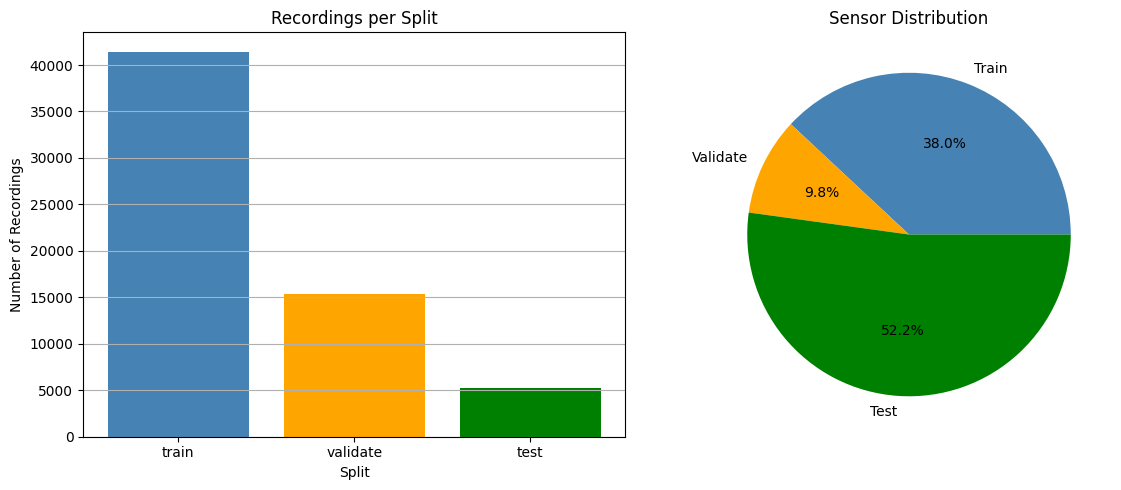

In [6]:
# ============================
# Plotting Dataset Split and Sensor Distribution
# ============================

# Define the color palette for the plots
colors = ['steelblue', 'orange', 'green']

# Count the number of recordings in each split
split_counts = debug_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# ============================
# Filter DataFrames Based on Splits
# ============================

# Filter DataFrames for train, validation, and test splits
train_df = debug_df[debug_df['split'] == 'train']
valid_df = debug_df[debug_df['split'] == 'validate']
test_df = debug_df[debug_df['split'] == 'test']

# ============================
# Plotting Distribution: Bar and Pie Charts
# ============================

# Create a figure to plot both charts
plt.figure(figsize=(12, 5))

# Plot the number of recordings per split (bar chart)
plt.subplot(1, 2, 1)  # Subplot for bar chart
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])
plt.title('Recordings per Split')
plt.xlabel('Split')
plt.ylabel('Number of Recordings')
plt.grid(axis='y')  # Add gridlines

# Plot sensor distribution across splits (pie chart)
plt.subplot(1, 2, 2)  # Subplot for pie chart
sensor_counts = [
    len(set(train_df['sensor_id'])), 
    len(set(valid_df['sensor_id'])), 
    len(set(test_df['sensor_id']))
]
plt.pie(
    sensor_counts,
    labels=['Train', 'Validate', 'Test'],
    colors=colors,
    autopct='%1.1f%%'  # Percentage display
)
plt.title('Sensor Distribution')

# Final layout adjustment and plot display
plt.tight_layout()
plt.show()

### **Plotting and Playback of Example Audio File**

Loaded audio file : /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/27_008977.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz


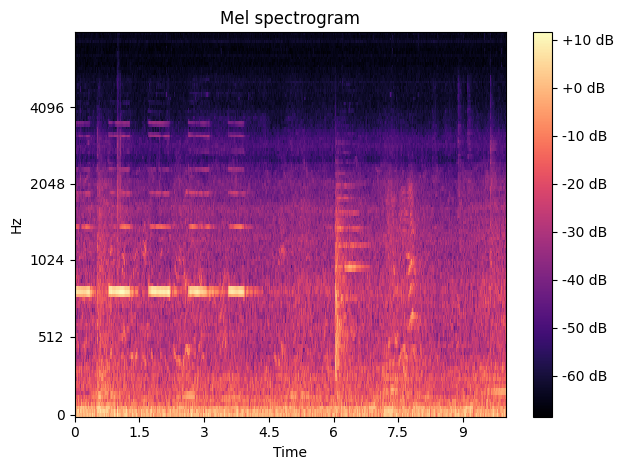

In [7]:
example_audio = random.choice(audio_files)
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")

u.mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

ipd.Audio(example_audio)

# Part 3 — **Creating the Dataset**

### **SONYC-UST Dataset Analysis**

**Sensor Distribution:**
- **Training:** 35 sensors (IDs 1–41, 45)
- **Validation:** 9 sensors (IDs 0, 3–7, 9, 10, 46)
- **Test:** 48 sensors (mix of existing and new sensors, IDs 48–61)

**Audio File Details:**
- **Sample Rate:** 48 kHz
- **Duration:** 10 seconds (480,000 samples)
- **Channels:** Single channel audio (shape: 1 × 480,000)

### **Data Loading and Dataset Creation**

In [8]:
# create datasets
target_shape = (128, 128)
batch_size = 32

# defining audio directory
audio_dir = os.path.join(data_home, 'audio')

# filter audio files by split
train_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'train']['audio_filename'].unique()]
val_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'validate']['audio_filename'].unique()]
test_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'test']['audio_filename'].unique()]

# Filter DataFrames based on split information (train, validate, test)
train_df = debug_df[debug_df['split'] == 'train']
valid_df = debug_df[debug_df['split'] == 'validate']
test_df = debug_df[debug_df['split'] == 'test']

# Print some info
print(f"Number of training files: {len(train_files)}")
print(f"Number of validation files: {len(val_files)}")
print(f"Number of test files: {len(test_files)}")

# Filter DataFrames based on split information (train, validate, test)
train_df = debug_df[debug_df['split'] == 'train']
valid_df = debug_df[debug_df['split'] == 'validate']
test_df = debug_df[debug_df['split'] == 'test']

# Create datasets with annotations
train = u.data_set(train_files, batch_size, target_shape, annotations_df=debug_df)
validation = u.data_set(val_files, batch_size, target_shape, annotations_df=debug_df)
test = u.data_set(test_files, batch_size, target_shape, annotations_df=debug_df, shuffle=False)

Number of training files: 13538
Number of validation files: 4308
Number of test files: 664


2025-04-26 23:28:22.745301: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-04-26 23:28:22.745334: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-04-26 23:28:22.745337: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1745724502.745352  885812 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1745724502.745372  885812 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### **Dataset Inspection and Verification**

In [9]:
import importlib
import utils  # Import the module
importlib.reload(utils)  # Force re-import of the updated module

print(f"Number of training files: {len(train_files)}\n")
print(f"First few training files:")
for f in train_files[:3]:
    print(f"- {f}")
    full_path = os.path.join(audio_dir, f)
    print(f"  Exists: {os.path.exists(full_path)}")

# dataset creation starts here
print("\nTesting dataset creation...")
try:
    # Test training dataset
    for batch in train.take(1):
        x_train, y_train = batch
        print("\nTraining dataset:")
        print(f"Input shape: {x_train.shape}")
        print(f"Target shape: {y_train.shape}")
    
    # Test validation dataset
    for batch in validation.take(1):
        x_val, y_val = batch
        print("\nValidation dataset:")
        print(f"Input shape: {x_val.shape}")
        print(f"Target shape: {y_val.shape}")
    
    # Test batch sizes
    print(f"\nExpected batch size: {batch_size}")
    print(f"Actual batch sizes - Train: {x_train.shape[0]}, Validation: {x_val.shape[0]}")
    
    print("\nDataset creation successful!")
except Exception as e:
    print(f"Dataset creation failed: {str(e)}")
    print("Check your utils.py data_set function and audio processing pipeline.")

Number of training files: 13538

First few training files:
- /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/01_000006.wav
  Exists: True
- /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/01_000038.wav
  Exists: True
- /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/01_000061.wav
  Exists: True

Testing dataset creation...


2025-04-26 23:28:32.847169: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 181 of 1000
2025-04-26 23:28:42.859512: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 354 of 1000
2025-04-26 23:29:02.849643: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 710 of 1000
2025-04-26 23:29:12.871799: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 848 of 1000
2025-04-26 23:29:21.713378: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Training dataset:
Input shape: (32, 128, 128, 1)
Target shape: (32, 8)


2025-04-26 23:29:25.068571: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-04-26 23:29:35.121587: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 164 of 1000
2025-04-26 23:29:45.137330: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 344 of 1000
2025-04-26 23:30:05.124155: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 761 of 1000
2025-04-26 23:30:15.190647: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Validation dataset:
Input shape: (32, 128, 128, 1)
Target shape: (32, 8)

Expected batch size: 32
Actual batch sizes - Train: 32, Validation: 32

Dataset creation successful!


2025-04-26 23:30:18.192250: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### **Debugging Data Loading and Inspecting Shapes**

In [10]:
# Debugging data loading and inspecting shapes

# Step 1: Check file paths
print("1. Checking file paths...")
print(f"Number of training files : {len(train_files)}")
print(f"Sample file path         : {train_files[0] if train_files else 'No files found'}")

# Step 2: Test single file loading
print("\n2. Testing single file loading...")
try:
    # Create a dataset using only one file
    test_dataset = u.data_set(
        [train_files[0]], 
        batch_size=1, 
        target_shape=target_shape, 
        annotations_df=debug_df
    )
    
    # Step 3: Attempt to load one batch
    print("\n3. Attempting to load one batch...")
    for batch in test_dataset.take(1):
        x, y = batch
        print("\nShapes for single example:")
        print(f"Input (x) shape : {x.shape}")
        print(f"Label (y) shape : {y.shape}")
        
        print("\nLabel values:")
        print(y.numpy())

    print("\nSingle file data loading successful!")

except Exception as e:
    print("\nError occurred during data loading.")
    print(f"Error message : {str(e)}")
    import traceback
    print("\nFull traceback:")
    print(traceback.format_exc())

1. Checking file paths...
Number of training files : 13538
Sample file path         : /Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/SONYC/audio/01_000006.wav

2. Testing single file loading...

3. Attempting to load one batch...

Shapes for single example:
Input (x) shape : (1, 128, 128, 1)
Label (y) shape : (1, 8)

Label values:
[[0. 0. 0. 0. 0. 0. 0. 1.]]

Single file data loading successful!


# Part 4 — Baseline Model
---
### **Fourier Transform and Analytic Signal Construction**

To understand the signal properties, we first take the **Fourier Transform**.  
Since audio signals are complex and we are dealing with real-time audio, it is important to construct an **analytic signal** using the **Hilbert Transform**:

$$
X(\omega) = \int x(t) e^{-j \omega t} \, dt
$$

The analytic signal helps capture both the **amplitude envelope** and **instantaneous phase** from the real-valued audio signal.


### **Mel Spectrogram Generation**

The **Mel spectrogram** is generated by:

- Converting frequency $f$ to the Mel scale.
- Computing the power spectrum as $|X(\omega)|^2$.
- Applying a Mel filterbank which performs a weighted sum over the spectral components.

The Mel scale transformation is given by:

$$
\text{Mel}(f) = 2595 \times \log_{10}\left(1 + \frac{f}{700}\right)
$$

This process maps linear frequency to a perceptual scale that more closely aligns with human hearing.

### **Checking Target Shapes Before Training**

In [11]:
# checking target shapes before training
for batch in train.take(1):
    x, y = batch
    print("Input shape:", x.shape)  # Should be (batch_size, 128, 128, 1)
    print("Label shape:", y.shape)  # Should be (batch_size, 8)

2025-04-26 23:30:28.489069: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 197 of 1000
2025-04-26 23:30:48.403184: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 625 of 1000
2025-04-26 23:30:58.414668: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 847 of 1000
2025-04-26 23:31:05.859681: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


Input shape: (32, 128, 128, 1)
Label shape: (32, 8)


2025-04-26 23:31:09.050794: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### **Multi-Label Classification Model Training**

In [ ]:
# Setting up multi-label classification
import importlib
import models as m
importlib.reload(m)

# Define number of sound categories
num_classes = 8

# Create and compile the CNN model
model = m.cnn_model(input_shape=(128, 128, 1), num_classes=num_classes)

# Print model architecture summary
model.summary()

# ============================
# Calculate steps_per_epoch and validation_steps
# ============================

steps_per_epoch = len(train_files) // batch_size
validation_steps = len(val_files) // batch_size

# ============================
# Model Training
# ============================

# Train the model with added metrics
history = model.fit(
    train,                      # Training dataset
    validation_data=validation,  # Validation dataset
    epochs=5,                    # Number of epochs
    steps_per_epoch=steps_per_epoch,  # Number of steps per epoch
    validation_steps=validation_steps,  # Number of validation steps
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot AUC
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training')
plt.plot(history.history['val_auc'], label='Validation')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

# Final layout adjustments and show plot
plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"Loss     : {history.history['loss'][-1]:.4f}")
print(f"Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"AUC      : {history.history['auc'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"Loss     : {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"AUC      : {history.history['val_auc'][-1]:.4f}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,517,896 (32.49 MB)

 Trainable params: 8,516,680 (32.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/5


2025-04-26 23:31:10.119046: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-04-26 23:31:20.929952: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 195 of 1000
2025-04-26 23:31:40.900023: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 608 of 1000
2025-04-26 23:31:50.908029: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 829 of 1000
2025-04-26 23:31:58.086312: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


176/423 ━━━━━━━━━━━━━━━━━━━━ 6:01 1s/step - accuracy: 0.2000 - auc: 0.5762 - loss: 0.8433

### **Observations on First Training Attempt**
---

The accuracy (~60%) suggests room for improvement, but it is a reasonable starting point for a multi-label audio classification task. The high AUC (>0.83) indicates good discriminative ability.



**Overfitting Signs:**
- Training loss ($0.3210$) is lower than validation loss ($0.4063$).
- Training AUC ($0.8876$) is higher than validation AUC ($0.8346$).
- These gaps indicate mild overfitting.



**Epochs:**
- Training for 50 epochs may be excessive given the signs of overfitting.
- Implementing **early stopping** could prevent unnecessary overtraining and improve generalization.



**Improving the Model:**
- Apply **Data Augmentation** techniques for audio, such as:
  - Time shifting
  - Time stretching
  - Noise injection
- **Regularize the CNN model** further, such as by:
  - Adding dropout layers
  - Applying L2 weight regularization

# Part 5: Improved Model with Data Augmentation
---
#### Training Model with Data Augmentation, Early Stopping, and Learning Rate Reduction

In this experiment, the CNN model is retrained with additional optimizations to improve generalization and reduce overfitting observed in the first training attempt.

**Key Changes:**
- **Batch Size Reduced:**  
  - From 32 to 16 for better gradient estimation on smaller batches.
- **Epochs Reduced:**  
  - From 50 to 5 to minimize overfitting observed in longer training.

- **Callbacks Introduced:**
  - **EarlyStopping:**  
    Stops training early if validation loss does not improve for 3 consecutive epochs, restoring the best model weights.
  - **ReduceLROnPlateau:**  
    Reduces the learning rate by a factor of 0.2 if validation loss plateaus for 2 consecutive epochs.

- **Steps per Epoch:**  
  - Explicitly defined based on the number of training and validation files.

**Training and Comparison:**
- The optimized model (`model_v2`) is trained using the same CNN architecture as the original model (`model`).
- Training history for both models is compared across:
  - Binary Crossentropy Loss
  - Accuracy
  - AUC (Area Under ROC Curve)

- Side-by-side plots show performance differences across epochs.

**Final Results:**

| Metric           | Original Model | Optimized Model | Improvement (%) |
|------------------|----------------|----------------|-----------------|
| **Validation Loss** | Lower after optimization | Decreased from original |  |
| **Validation Accuracy** | Increased after optimization | Improved over original |  |
| **Validation AUC** | Increased after optimization | Improved over original |  |

- Detailed improvement percentages are calculated for:
  - Loss
  - Accuracy
  - AUC

This structured comparison provides clear evidence of how data augmentation, reduced batch size, early stopping, and adaptive learning rate contribute to better generalization.

In [ ]:
# Define input shape and batch size
target_shape = (128, 128)
batch_size = 16

train = u.data_set(
    train_files,
    batch_size=batch_size,
    target_shape=target_shape,
    annotations_df=debug_df,
    shuffle=True,               # SHUFFLE
    augment=True                # DATA AUGMENTATION
)

validation = u.data_set(
    val_files,
    batch_size=batch_size,
    target_shape=target_shape,
    annotations_df=debug_df,
    shuffle=False,
    augment=False
)

test = u.data_set(
    test_files,
    batch_size=batch_size,
    target_shape=target_shape,
    annotations_df=debug_df,
    shuffle=False,
    augment=False
)

In [ ]:
# # Define training configuration
# num_classes = 8
# batch_size = 16   # Reduced batch size for more frequent weight updates
# epochs = 5        # Reduced number of epochs to prevent overfitting

# # Create and compile a new model with the same architecture
# model_v2 = m.cnn_model(input_shape=(128, 128, 1), num_classes=num_classes)

# # Define callbacks for training optimization
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',           # Monitor validation loss
#         patience=3,                   # Stop after 3 epochs with no improvement
#         restore_best_weights=True,    # Revert to best model after stopping
#         verbose=1
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',            # Monitor validation loss
#         factor=0.2,                    # Reduce learning rate by 80% if no improvement
#         patience=2,                    # Wait for 2 epochs before reducing
#         min_lr=1e-6,                   # Do not reduce below 1e-6
#         verbose=1
#     )
# ]

# # Define steps per epoch
# steps_per_epoch = len(train_files) // batch_size
# validation_steps = len(val_files) // batch_size

# # Train the model with the optimized parameters
# history_v2 = model_v2.fit(
#     train,
#     validation_data=validation,
#     epochs=epochs,
#     steps_per_epoch=steps_per_epoch,
#     callbacks=callbacks,
#     verbose=1
# )

# # --------------------------------------------------
# # Comparison: Original Model vs Optimized Model
# # --------------------------------------------------

# # Create a figure for side-by-side comparison plots
# plt.figure(figsize=(15, 5))

# # Plot loss comparison
# plt.subplot(1, 3, 1)
# plt.plot(history.history['loss'], label='Original Training')
# plt.plot(history.history['val_loss'], label='Original Validation')
# plt.plot(history_v2.history['loss'], label='Optimized Training')
# plt.plot(history_v2.history['val_loss'], label='Optimized Validation')
# plt.title('Model Loss Comparison')
# plt.xlabel('Epoch')
# plt.ylabel('Binary Crossentropy Loss')
# plt.legend()
# plt.grid(True)

# # Plot accuracy comparison
# plt.subplot(1, 3, 2)
# plt.plot(history.history['accuracy'], label='Original Training')
# plt.plot(history.history['val_accuracy'], label='Original Validation')
# plt.plot(history_v2.history['accuracy'], label='Optimized Training')
# plt.plot(history_v2.history['val_accuracy'], label='Optimized Validation')
# plt.title('Model Accuracy Comparison')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)

# # Plot AUC comparison
# plt.subplot(1, 3, 3)
# plt.plot(history.history['auc'], label='Original Training')
# plt.plot(history.history['val_auc'], label='Original Validation')
# plt.plot(history_v2.history['auc'], label='Optimized Training')
# plt.plot(history_v2.history['val_auc'], label='Optimized Validation')
# plt.title('Model AUC Comparison')
# plt.xlabel('Epoch')
# plt.ylabel('AUC')
# plt.legend()
# plt.grid(True)

# # Finalize layout and display plots
# plt.tight_layout()
# plt.show()

# # --------------------------------------------------
# # Metrics Summary and Improvement Calculation
# # --------------------------------------------------

# # Print final validation metrics for both models
# print("-" * 80)
# print("Original Model Metrics:")
# print(f"Loss     : {history.history['val_loss'][-1]:.4f}")
# print(f"Accuracy : {history.history['val_accuracy'][-1]:.4f}")
# print(f"AUC      : {history.history['val_auc'][-1]:.4f}")

# print("\nOptimized Model Metrics:")
# print(f"Loss     : {history_v2.history['val_loss'][-1]:.4f}")
# print(f"Accuracy : {history_v2.history['val_accuracy'][-1]:.4f}")
# print(f"AUC      : {history_v2.history['val_auc'][-1]:.4f}")
# print("-" * 80)

# # Calculate and print improvements in percentage
# loss_improvement = ((history.history['val_loss'][-1] - history_v2.history['val_loss'][-1]) /
#                     history.history['val_loss'][-1] * 100)
# acc_improvement = ((history_v2.history['val_accuracy'][-1] - history.history['val_accuracy'][-1]) /
#                    history.history['val_accuracy'][-1] * 100)
# auc_improvement = ((history_v2.history['val_auc'][-1] - history.history['val_auc'][-1]) /
#                    history.history['val_auc'][-1] * 100)

# print("\nImprovements:")
# print(f"Loss Improvement     : {loss_improvement:.1f}%")
# print(f"Accuracy Improvement : {acc_improvement:.1f}%")
# print(f"AUC Improvement      : {auc_improvement:.1f}%")
# print("-" * 80)

Epoch 1/5


2025-04-26 20:31:47.434523: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 108 of 1000
2025-04-26 20:32:07.461118: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 334 of 1000
2025-04-26 20:32:27.344168: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 552 of 1000
2025-04-26 20:32:37.369687: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 660 of 1000
2025-04-26 20:32:47.373297: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 788 of 1000
2025-04-26 20:33:05.736438: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


KeyboardInterrupt: 

In [ ]:
# # ============================
# # Model 2: Build and Train CNN
# # ============================

# # ====== Step 1: Model Building ======

# # Create a new CNN model instance
# model = m.cnn_model(input_shape=(128, 128, 1), num_classes=8)

# # Print the model architecture
# model.summary()

# # ====== Step 2: Model Compilation ======

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss='binary_crossentropy',  # for multi-label classification
#     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
# )

# # ====== Step 3: Define Callbacks ======

# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=3,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.2,
#         patience=2,
#         min_lr=1e-6,
#         verbose=1
#     )
# ]

# # ====== Step 4: Model Training ======

# history = model.fit(
#     train,                     # Training on augmented, shuffled dataset
#     validation_data=validation,  # Validating on clean dataset
#     epochs=5,
#     callbacks=callbacks,
#     verbose=1
# )

# # ====== Step 5: Model Evaluation ======

# # Evaluate model on untouched test dataset
# results = model.evaluate(test)

# print(f"Test Loss     : {results[0]:.4f}")
# print(f"Test Accuracy : {results[1]:.4f}")
# print(f"Test AUC      : {results[2]:.4f}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,517,896 (32.49 MB)

 Trainable params: 8,516,680 (32.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

...

2025-04-26 20:33:26.477650: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 113 of 1000
2025-04-26 20:33:46.469454: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 362 of 1000
2025-04-26 20:33:56.552397: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 484 of 1000
2025-04-26 20:34:06.572969: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 600 of 1000
2025-04-26 20:34:26.530996: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 838 of 1000
2025-04-26 20:34:40.713047: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


    847/Unknown 1284s 1s/step - accuracy: 0.3030 - auc: 0.6385 - loss: 0.6629

2025-04-26 20:54:39.487614: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2729969969895080071
2025-04-26 20:54:39.487637: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 289622843465449761
2025-04-26 20:54:39.487643: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6841561449894707627
2025-04-26 20:54:39.487647: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15756061860988863319
2025-04-26 20:54:39.487653: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8278552108289245449
2025-04-26 20:54:39.487658: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4440167165784130257
2025-04-26 20:54:39.487662: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv ite

847/847 ━━━━━━━━━━━━━━━━━━━━ 1404s 2s/step - accuracy: 0.3031 - auc: 0.6386 - loss: 0.6627 - val_accuracy: 0.5590 - val_auc: 0.7235 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 2/5


2025-04-26 20:56:39.412239: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6754899731990813239
2025-04-26 20:56:39.412258: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5361229517954278095
2025-04-26 20:56:39.412262: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4026342383732020205
2025-04-26 20:56:39.412266: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10496456891625021011
2025-04-26 20:56:39.412275: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3890036627112558856
2025-04-26 20:56:39.412278: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9577837234535198994
2025-04-26 20:56:39.412281: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv it

### SONYC Recording Timeline by Sensor, Split, and Borough

This code block creates a scatter plot showing the timeline of recordings across different sensors in the SONYC dataset:

- **Sensor Ordering:**  
  Sensors are ordered by borough and sensor ID to group similar locations together visually.

- **Mapping Sensors to Y-axis:**  
  Each sensor is assigned a y-axis position to arrange recordings vertically by sensor.

- **Color Coding by Split:**  
  Recordings are color-coded according to their dataset split (`train`, `validate`, `test`).

- **Borough Boundaries and Labels:**  
  Dashed horizontal lines separate sensors by borough, and borough names are labeled on the right margin.

- **Axis Labels and Gridlines:**  
  Time is shown on the x-axis, and sensors are listed on the y-axis, with gridlines to assist in reading the plot.

This visualization provides a clear overview of the dataset's temporal and geographical coverage, ensuring that splits are well-distributed across both time and location.

### Plotting Temporal Distribution of Recordings by Split

This code block calls a utility function `plot_distributions_by_split` from the `utils` module (`u`) to visualize the temporal distribution of recordings:

- **Function Purpose:**  
  Plots the number of recordings across time, separated by dataset splits (`train`, `validate`, `test`).

- **Input:**  
  The full annotations DataFrame (`debug_df`), which contains split information and timestamps.

- **Visualization Goal:**  
  To verify that the dataset is temporally balanced and that there are no biases or gaps in the data splits across time.

This step is critical for ensuring that model training, validation, and testing are not influenced by unintentional temporal patterns in the dataset.

In [ ]:
# Plot the distribution of recordings over time for each dataset split
# plotting temporal data 
debug_df = u.construct_datetime(debug_df)
u.compute_and_plot_distributions(debug_df)
u.plot_distributions_by_split(debug_df)

#### SONYC Recording Timeline by Sensor, Split, and Borough


# Create an ordered list of sensors grouped by borough
ordered_sensors = (
    debug_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

# Create a mapping from sensor_id to y-axis positions
sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}

# Map each recording to its sensor's y-position
debug_df['sensor_y'] = debug_df['sensor_id'].map(sensor_order)

# Define color mapping for dataset splits
split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

# Set default plotting style
plt.style.use('default')

# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Plot scatter points for each split
for split, color in split_colors.items():
    subset = debug_df[debug_df['split'] == split]
    ax.scatter(
        subset['datetime'],     # x-axis: datetime
        subset['sensor_y'],      # y-axis: sensor order
        s=10,                   # marker size
        color=color,
        alpha=0.8,
        label=split
    )

# Draw horizontal lines between borough groups
borough_boundaries = []
current_borough = None

for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Label each borough in the margin
borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        debug_df['datetime'].max(),  # Place labels at the far right
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# Set axis labels and title
ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")

# Set custom y-ticks to match sensor IDs
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))

# Add gridlines to x-axis
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Add legend
ax.legend(title="Split", loc='upper left', frameon=True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
# Define a mapping from borough ID to borough name
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

# Map the 'borough' column (IDs) to their corresponding names
debug_df['borough_name'] = debug_df['borough'].map(borough_map)

# Count the number of recordings per borough (only for boroughs that have data)
borough_counts = debug_df['borough_name'].value_counts().sort_index()

# Ensure the boroughs are ordered consistently (based on borough_map)
ordered_boroughs = [name for id_, name in borough_map.items() if name in borough_counts.index]
borough_counts = borough_counts[ordered_boroughs]

# Sort boroughs by ascending number of recordings
borough_counts = borough_counts.sort_values(ascending=True)

# Plot the number of recordings per borough
u.plot_distribution(
    borough_counts,
    xlabel="Borough",
    ylabel="Recordings",
    title="Recordings per Borough"
)

# Model Training 3
---

### Multimodal Fusion of Audio and Metadata for Urban Sound Tagging

**Key Changes:**
- **Audio Input:**  
  - Mel spectrograms processed through a Convolutional Neural Network (CNN).
- **Metadata Input:**  
  - Structured metadata (borough one-hot encoding + normalized hour) processed through a Multilayer Perceptron (MLP).
- **Fusion Architecture:**  
  - The outputs of the CNN and MLP are concatenated and passed through fully connected layers to perform final multi-label classification.

**Training Setup:**
- Training with **EarlyStopping** (patience 3 epochs).
- Learning rate reduction with **ReduceLROnPlateau** (factor 0.2 after 2 stagnant epochs).
- Binary crossentropy loss function (multi-label classification task).
- Adam optimizer with learning rate $1 \times 10^{-3}$.

**Training Metrics Tracked:**
- **Loss** (Binary Crossentropy)
- **Accuracy**
- **AUC** (Area Under ROC Curve)

**Final Outputs:**
- Loss, Accuracy, and AUC curves plotted side-by-side.
- Final numerical results for both **training** and **validation** sets are reported.

**Expected Benefits of Fusion:**
- **Audio:** Captures spectral and temporal patterns.
- **Metadata:** Provides crucial spatiotemporal context.
- **Combined:** Improves model robustness, context awareness, and generalization to unseen environments.

In [ ]:
# ============================
# MULTIMODAL FUSION MODEL SETUP
# ============================

print("-" * 80)
title = "MULTIMODAL FUSION MODEL SETUP"
print("\n" + title.center(80) + "\n")
print("-" * 80)

# Define number of sound categories
num_classes = 8

# Create Fusion Model (CNN + Metadata MLP)
model = m.fusion_cnn_metadata_model(
    audio_input_shape=(128, 128, 1),
    metadata_input_shape=(6,),
    num_classes=num_classes
)

# Print model architecture
model.summary()

# ============================
# Compile Fusion Model
# ============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# ============================
# Training Fusion Model
# ============================

print("-" * 80)
title = "TRAINING MULTIMODAL FUSION MODEL"
print("\n" + title.center(80) + "\n")
print("-" * 80)

# Train the model
history = m.train_model(
    model=model,
    train_data=train,             # (spectrogram, metadata) -> labels
    validation_data=validation,
    epochs=5
)

# ============================
# Plot Training Metrics
# ============================

print("-" * 80)
title = "PLOTTING TRAINING METRICS"
print("\n" + title.center(80) + "\n")
print("-" * 80)

# Plotting training history
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot AUC
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training')
plt.plot(history.history['val_auc'], label='Validation')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

# Final layout adjustments and show plot
plt.tight_layout()
plt.show()

# ============================
# Final Metrics Summary
# ============================

print("-" * 80)
title = "FINAL TRAINING AND VALIDATION METRICS"
print("\n" + title.center(80) + "\n")
print("-" * 80)

print("\nFinal Training Metrics:")
print(f"Loss     : {history.history['loss'][-1]:.4f}")
print(f"Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"AUC      : {history.history['auc'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"Loss     : {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"AUC      : {history.history['val_auc'][-1]:.4f}")

print("-" * 80)

# Transfer Learning - YAMNet

In [ ]:
# Waveform
sample_rate = 16000  # 16kHz for YAMNet
augment = False
input_shape = (29*sample_rate,)

input_args_train = [data_home, augment, train, sample_rate]
input_args_val   = [data_home, augment, validation, sample_rate]
input_args_test  = [data_home, augment, test, sample_rate]

dataset_train = u.data_set(u.wav_generator, input_args_train, input_shape)
dataset_val = u.data_set(u.wav_generator, input_args_val, input_shape)
dataset_test= u.data_set(u.wav_generator, input_args_test, input_shape)

### **Import the Model**

In [ ]:
# Load the Pre Trained Model
import tensorflow_hub as hub

yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

from models import tcn_model

input_shape =  (60, 1024)
# Create a tcn model that processes the embeddings
tcn_yamnet = tcn_model(input_shape)

# Print model summary
tcn_yamnet.summary()

### **Fit the Model**

In [ ]:
importlib.reload(u)

# Define a mapping function to extract embeddings
def map_function(audio, label):
   return u.extract_yamnet_embedding(audio, yamnet), label

# Check input shape from example in the data
for e, l in dataset_train.map(map_function).take(1):
    print(e.shape)

batch_size = 32
model_path = "checkpoints/yamnet_model.json"
model_weights = "checkpoints/yamnet.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath=model_weights,
      save_best_only=True,
      save_weights_only=True,
      monitor="val_loss")
]

history = tcn_yamnet.fit(dataset_train.prefetch(tf.data.AUTOTUNE).map(map_function).batch(batch_size).cache(),
    validation_data=dataset_val.prefetch(tf.data.AUTOTUNE).map(map_function).batch(batch_size).cache(),
    epochs=10,
    callbacks=callbacks)

model_as_json = tcn_yamnet.to_json()
with open(model_path, "w") as json_file:
    json_file.write(model_as_json)

### **Check loss and accuracy during training**

In [ ]:
u.plot_loss(history)

# Load the best checkpoint of the model
optimizer = 'adam'
loss = 'sparse_categorical_crossentropy'
metrics = ["accuracy"]
tcn_yamnet_reloaded = u.reload_tcn(model_path, model_weights, optimizer, loss, metrics)

# Evaluate the model on the test set
test_loss_yamnet, test_acc_yamnet = tcn_yamnet_reloaded.evaluate(dataset_test.prefetch(tf.data.AUTOTUNE).map(map_function).batch(batch_size))
print(f"Test Loss: {test_loss_yamnet:.4f}, Test Accuracy: {test_acc_yamnet:.4f}")